In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# ============================================================
# 1. LOAD DATA
# ============================================================

train = pd.read_csv("C:\\Users\\bharath simha reddy\\Desktop\\genai_journey\\ML\\Working_Categorical\\Data\\train.csv")
test = pd.read_csv("C:\\Users\\bharath simha reddy\\Desktop\\genai_journey\\ML\\Working_Categorical\\Data\\test.csv")

test_ids = test["PassengerId"].copy()

# ============================================================
# 2. SEPARATE TARGET
# ============================================================

y = train["Survived"]

train_features = train.drop(columns=["Survived"])

# ============================================================
# 3. COMBINE TRAIN + TEST
# ============================================================

combined = pd.concat(
    [train_features, test],
    axis=0,
    ignore_index=True
)

# ============================================================
# 4. FEATURE ENGINEERING
# ============================================================

# ---- Name Title ----

combined["NameTitle"] = combined["Name"].str.extract(
    r',\s*([^\.]+)\.',
    expand=False
)

combined["NameTitle"] = combined["NameTitle"].replace({
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs"
})

rare_titles = [
    "Lady",
    "Countess",
    "Capt",
    "Col",
    "Don",
    "Dr",
    "Major",
    "Rev",
    "Sir",
    "Jonkheer",
    "Dona"
]

combined["NameTitle"] = combined["NameTitle"].replace(
    rare_titles,
    "Rare"
)

common_titles = ["Mr", "Mrs", "Miss", "Master"]

combined["NameTitle"] = np.where(
    combined["NameTitle"].isin(common_titles),
    combined["NameTitle"],
    "Rare"
)

# ============================================================
# 5. MISSING VALUE HANDLING
# ============================================================

combined["Fare"] = combined["Fare"].fillna(
    combined["Fare"].median()
)

combined["Age"] = combined.groupby(
    "NameTitle"
)["Age"].transform(
    lambda x: x.fillna(x.median())
)

combined["Age"] = combined["Age"].fillna(
    combined["Age"].median()
)

combined["Embarked"] = combined["Embarked"].fillna(
    combined["Embarked"].mode()[0]
)

# ============================================================
# 6. ADDITIONAL FEATURES
# ============================================================

combined["FamilySize"] = (
    combined["SibSp"] +
    combined["Parch"] +
    1
)

combined["IsAlone"] = (
    combined["FamilySize"] == 1
).astype(int)

combined["FarePerPerson"] = (
    combined["Fare"] /
    combined["FamilySize"]
)

# ============================================================
# 7. DECK FEATURE
# ============================================================

combined["Deck"] = combined["Cabin"].str[0]

combined["Deck"] = combined["Deck"].fillna(
    "Unknown"
)

# ============================================================
# 8. LOG TRANSFORM FARE
# ============================================================

combined["Fare"] = np.log1p(combined["Fare"])

# ============================================================
# 9. AGE BANDS
# ============================================================

combined["AgeBand"] = pd.cut(
    combined["Age"],
    bins=[0, 16, 32, 48, 64, 80],
    labels=False,
    include_lowest=True
)

# ============================================================
# 10. FARE BANDS
# ============================================================

combined["FareBand"] = pd.qcut(
    combined["Fare"],
    q=4,
    labels=False,
    duplicates="drop"
)

# ============================================================
# 11. ENCODE SEX
# ============================================================

combined["Sex"] = combined["Sex"].map({
    "male": 0,
    "female": 1
})

# ============================================================
# 12. ONE-HOT ENCODING
# ============================================================

combined = pd.get_dummies(
    combined,
    columns=[
        "Embarked",
        "NameTitle",
        "Deck"
    ],
    drop_first=True
)

# ============================================================
# 13. DROP UNUSED COLUMNS
# ============================================================

combined = combined.drop(
    columns=[
        "PassengerId",
        "Name",
        "Ticket",
        "Cabin"
    ]
)

# ============================================================
# 14. CONVERT BOOL TO INT
# ============================================================

bool_cols = combined.select_dtypes(
    include="bool"
).columns

combined[bool_cols] = combined[
    bool_cols
].astype(int)

# ============================================================
# 15. SPLIT BACK TRAIN / TEST
# ============================================================

n_train = len(train)

X_train = combined.iloc[:n_train].copy()
X_test = combined.iloc[n_train:].copy()

# ============================================================
# 16. SCALE DATA FOR LOGISTIC REGRESSION
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================
# 17. DEFINE MODELS
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        solver="liblinear",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
}

# ============================================================
# 18. CROSS VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = {}

print("\nCross Validation Results")
print("=" * 60)

for name, model in models.items():

    if name == "Logistic Regression":
        scores = cross_val_score(
            model,
            X_train_scaled,
            y,
            cv=cv,
            scoring="accuracy"
        )
    else:
        scores = cross_val_score(
            model,
            X_train,
            y,
            cv=cv,
            scoring="accuracy"
        )

    results[name] = scores

    print(
        f"{name:<20} "
        f"Mean={scores.mean():.4f} "
        f"Std={scores.std():.4f}"
    )

# ============================================================
# 19. SELECT BEST MODEL
# ============================================================

best_name = max(
    results,
    key=lambda x: results[x].mean()
)

best_model = models[best_name]

print("\nBest Model:", best_name)
print(
    "Best CV Accuracy:",
    round(results[best_name].mean(), 4)
)

# ============================================================
# 20. TRAIN BEST MODEL
# ============================================================

if best_name == "Logistic Regression":

    best_model.fit(
        X_train_scaled,
        y
    )

    predictions = best_model.predict(
        X_test_scaled
    )

else:

    best_model.fit(
        X_train,
        y
    )

    predictions = best_model.predict(
        X_test
    )

predictions = predictions.astype(int)

# ============================================================
# 21. FEATURE IMPORTANCE
# ============================================================

print("\nTop Features")
print("=" * 60)

if hasattr(best_model, "feature_importances_"):

    importance = pd.Series(
        best_model.feature_importances_,
        index=X_train.columns
    )

    print(
        importance
        .sort_values(ascending=False)
        .head(15)
    )

elif hasattr(best_model, "coef_"):

    coef = pd.Series(
        np.abs(best_model.coef_[0]),
        index=X_train.columns
    )

    print(
        coef
        .sort_values(ascending=False)
        .head(15)
    )

# ============================================================
# 22. CREATE SUBMISSION
# ============================================================

submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Survived": predictions
})

submission.to_csv(
    "submission.csv",
    index=False
)

print("\nsubmission.csv created successfully!")
print(submission.head())


Cross Validation Results
Logistic Regression  Mean=0.8260 Std=0.0169
Random Forest        Mean=0.8170 Std=0.0237
Gradient Boosting    Mean=0.8372 Std=0.0109
XGBoost              Mean=0.8384 Std=0.0117

Best Model: XGBoost
Best CV Accuracy: 0.8384

Top Features
NameTitle_Mr      0.320480
Sex               0.121404
Pclass            0.089926
NameTitle_Rare    0.059526
FamilySize        0.045449
Deck_Unknown      0.036604
SibSp             0.027371
FarePerPerson     0.025974
NameTitle_Mrs     0.024851
NameTitle_Miss    0.022759
Embarked_S        0.022325
Age               0.021955
AgeBand           0.021565
Fare              0.020697
Deck_E            0.020205
dtype: float32

submission.csv created successfully!
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1


C:\Users\bharath simha reddy\AppData\Local\Temp\ipykernel_8440\1123641292.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train, x="Survived", palette="muted")
C:\Users\bharath simha reddy\AppData\Local\Temp\ipykernel_8440\1123641292.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cv_means.values, y=cv_means.index, palette="Blues_d")
C:\Users\bharath simha reddy\AppData\Local\Temp\ipykernel_8440\1123641292.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")


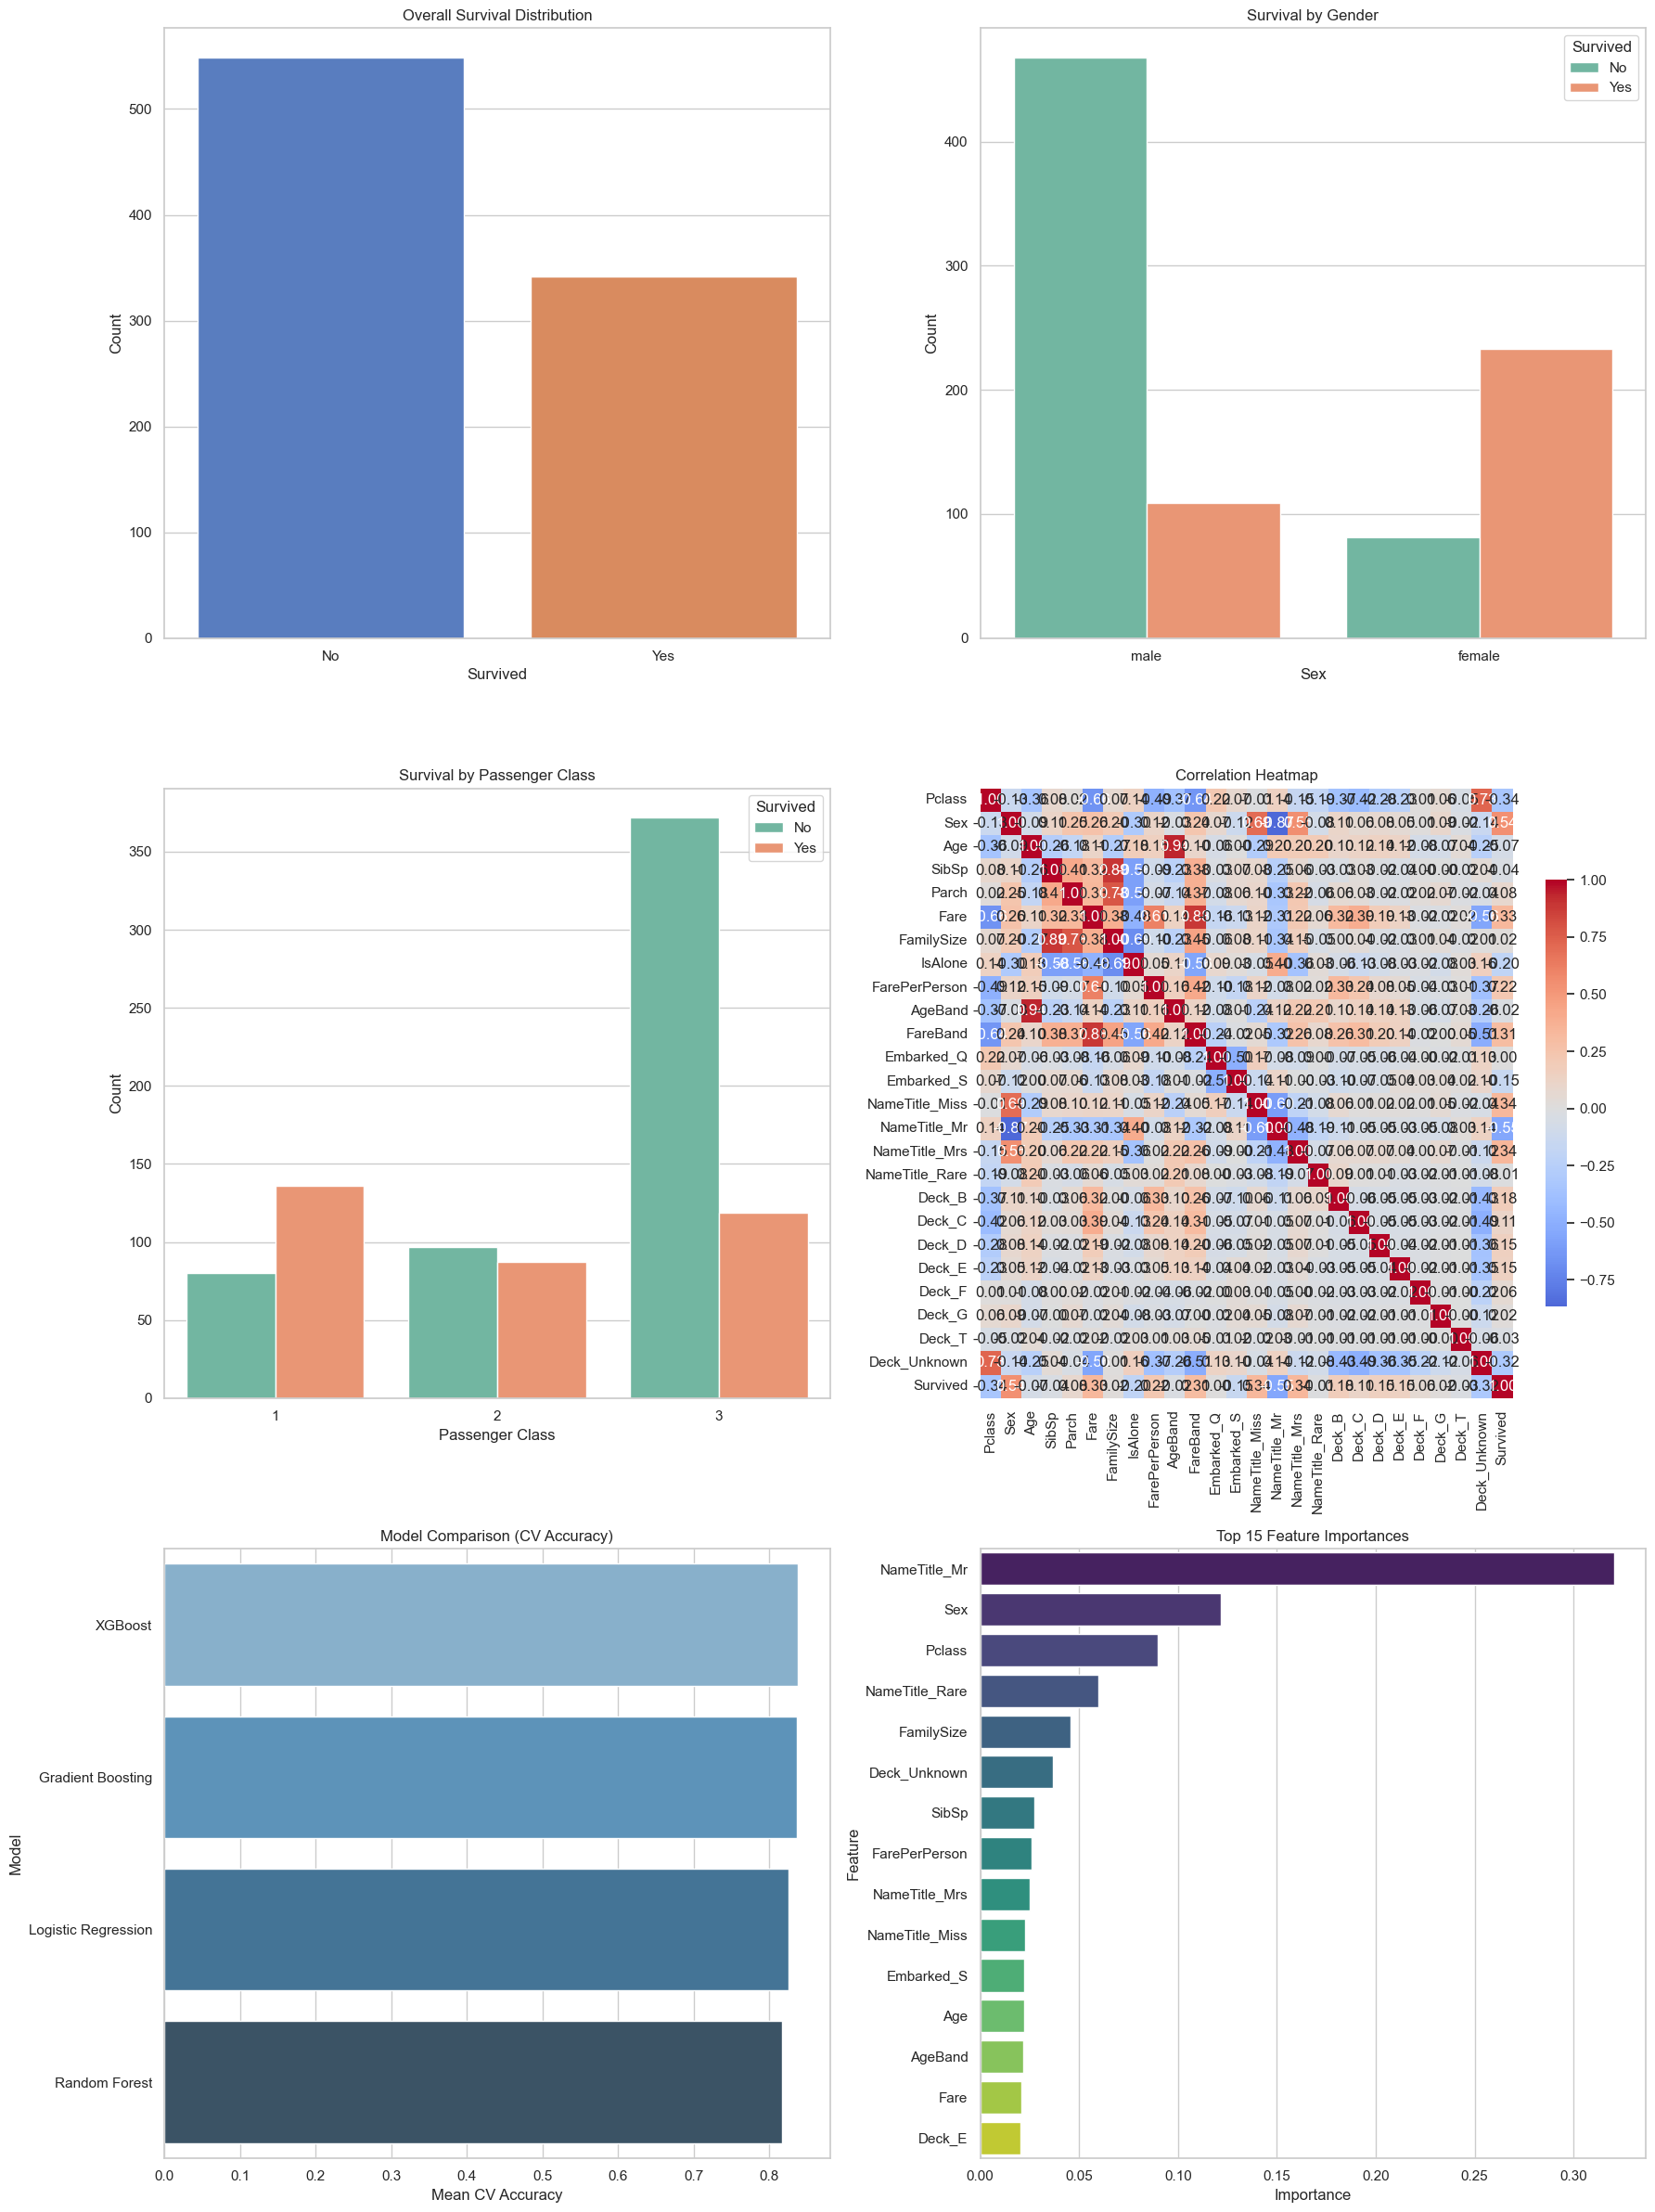

In [5]:
import seaborn as sns

import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

plt.figure(figsize=(18, 24))

# 1. Overall Survival Distribution
plt.subplot(3, 2, 1)
sns.countplot(data=train, x="Survived", palette="muted")
plt.title("Overall Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.xticks([0, 1], ["No", "Yes"])

# 2. Survival by Gender
plt.subplot(3, 2, 2)
sns.countplot(data=train, x="Sex", hue="Survived", palette="Set2")
plt.title("Survival by Gender")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.legend(title="Survived", labels=["No", "Yes"])

# 3. Survival by Passenger Class
plt.subplot(3, 2, 3)
sns.countplot(data=train, x="Pclass", hue="Survived", palette="Set2")
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.legend(title="Survived", labels=["No", "Yes"])

# 4. Correlation Heatmap
corr_df = X_train.copy()
corr_df["Survived"] = y
corr = corr_df.corr()

plt.subplot(3, 2, 4)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, cbar_kws={"shrink": 0.7})
plt.title("Correlation Heatmap")

# 5. Model Comparison (CV Accuracy)
plt.subplot(3, 2, 5)
cv_means = pd.Series({name: scores.mean() for name, scores in results.items()})
cv_means = cv_means.sort_values(ascending=False)
sns.barplot(x=cv_means.values, y=cv_means.index, palette="Blues_d")
plt.title("Model Comparison (CV Accuracy)")
plt.xlabel("Mean CV Accuracy")
plt.ylabel("Model")

# 6. Feature Importance
plt.subplot(3, 2, 6)
top_features = importance.sort_values(ascending=False).head(15)
sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [6]:
import os

out_dir = r"C:\Users\bharath simha reddy\Desktop\genai_journey\ML\Working_Categorical\Png"
os.makedirs(out_dir, exist_ok=True)

# 1. Overall Survival Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=train, x="Survived", palette="muted")
plt.title("Overall Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.xticks([0, 1], ["No", "Yes"])
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "overall_survival.png"), dpi=300)
plt.close()

# 2. Survival by Gender
plt.figure(figsize=(6, 4))
sns.countplot(data=train, x="Sex", hue="Survived", palette="Set2")
plt.title("Survival by Gender")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "survival_by_gender.png"), dpi=300)
plt.close()

# 3. Survival by Passenger Class
plt.figure(figsize=(6, 4))
sns.countplot(data=train, x="Pclass", hue="Survived", palette="Set2")
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "survival_by_pclass.png"), dpi=300)
plt.close()

# 4. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, cbar_kws={"shrink": 0.7})
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "correlation_heatmap.png"), dpi=300)
plt.close()

# 5. Model Comparison (CV Accuracy)
plt.figure(figsize=(6, 4))
cv_means = pd.Series({name: scores.mean() for name, scores in results.items()})
cv_means = cv_means.sort_values(ascending=False)
sns.barplot(x=cv_means.values, y=cv_means.index, palette="Blues_d")
plt.title("Model Comparison (CV Accuracy)")
plt.xlabel("Mean CV Accuracy")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "model_comparison_cv_accuracy.png"), dpi=300)
plt.close()

# 6. Feature Importance (Top 15)
plt.figure(figsize=(8, 6))
top_features = importance.sort_values(ascending=False).head(15)
sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "top15_feature_importance.png"), dpi=300)
plt.close()

C:\Users\bharath simha reddy\AppData\Local\Temp\ipykernel_8440\1039921249.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train, x="Survived", palette="muted")
C:\Users\bharath simha reddy\AppData\Local\Temp\ipykernel_8440\1039921249.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cv_means.values, y=cv_means.index, palette="Blues_d")
C:\Users\bharath simha reddy\AppData\Local\Temp\ipykernel_8440\1039921249.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")
